<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/MCMC/Fit_Models_to_Microlensing_lightcurves_solns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting two models to Microlensing photometry

In this exercise, we will fit a Gaussian distribution and a Cauchy distribution to a light curve of a single-lens microlensing event. 

    

# initial imports

In [37]:
!pip install emcee
!pip install corner

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import emcee
import corner
from scipy.optimize import minimize
%matplotlib inline

# Read in the input dataset

In [39]:
# OGLE data: https://raw.githubusercontent.com/Somayeh91/Data_Science_class_UD_fall_2021/main/data/OGLE_2012_BLG_1323.csv
# Roman data: https://raw.githubusercontent.com/Somayeh91/Data_Science_class_UD_fall_2021/main/data/mag.dcnormffp_0_82_1902.det.lc.W149.csv 
path  = "https://raw.githubusercontent.com/Somayeh91/Data_Science_class_UD_fall_2021/main/data//mag.dcnormffp_0_82_1902.det.lc.W149.csv"
df = pd.read_csv(path)

#Visualize the data

Text(0, 0.5, 'Magnification')

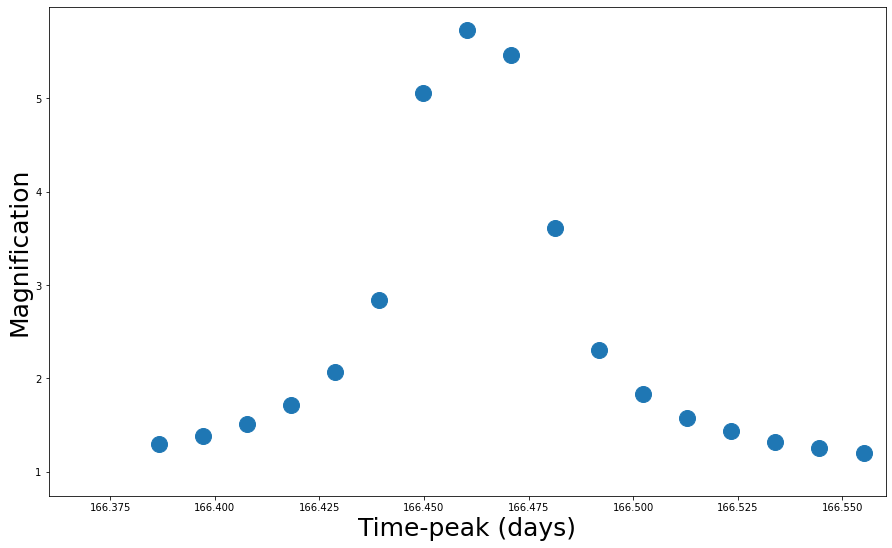

In [40]:
plt.figure(figsize=(15,9))
dt = .1
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt='o', ms=16)
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)', size = 25)
plt.ylabel('Magnification', size = 25)


# Define the PSPL model and the Cauchy distributions


PSPL model:

$F(t) = f_s \times A(t) + (1-f_s)$

$A(t) = \frac{u(t)^2 +2}{u(t)\times \sqrt{u(t)^2 + 4}}$

$u(t) = \sqrt {{u_0}^2+ ({\frac {t-t_0}{t_E}})^2}$

Cauchy model:

$C(t) = 1+ \frac {amp}{{1+|\frac{t-t_0}{\sigma}|}^{2b}}$


In [41]:
def PSPL(x, x0, tE, u0, fs):
    """Function describing a Gaussian of the form:
    f(x; x0, tE, u0, fs) = fs * A +(1 - fs)
    where A = ((u**2) + 2)/(u * np.sqrt(u**2 + 4)) and u = np.sqrt(u0**2 + ((t - x0) / tE)**2)
    
    Inputs:
    :param  np.array x: Series of intervals at which the function should be evaluated
    :param float x0, tE, u0, fs: Coefficients of the PSPL function
    
    Returns:
    :param np.array f(x): Series of function values at the intervals in x
    """
    u = np.sqrt(u0**2 + ((x - x0) / tE)**2)
    A = ((u**2) + 2)/(u * np.sqrt(u**2 + 4))
    F = fs * A +(1 - fs)

    return F

def cauchy(x, amp, x0, flattness, sigma):
    """Function describing a Cauchy of the form:
    f(x; amp, x0, flattness, sigma) = amp / [1 + |(x - x0) / sigma| ^ (2 * flattness)]
    
    Inputs:
    :param  np.array x: Series of intervals at which the function should be evaluated
    :param float amp, x0, flattness, sigma: Coefficients of the Cauchy function
    
    Returns:
    :param np.array f(x): Series of function values at the intervals in x
    """

    return amp / (1.0 + (abs((x - x0) / sigma))**(2.0 * flattness)) + 1



def l1(args, x, y, func=PSPL):
  '''l1 target function: returns value of l1 for given arguments and data for an arbitrary model
      arg: (array) model arguments (parameters)
      x: the exogenous variable (array)
      y: the exogenous variable (array)
      returns L1 sum of difference between prediction and data
      '''
  return np.sum(np.abs(y - func(x, *args)))

def l2(args, x, y, func=PSPL):
    '''l2 target function: returns value of l2 for given arguments and data for an arbitrary model
    arg: (array) model arguments (parameters)
    x: the exogenous variable (array)
    y: the exogenous variable (array)
    returns L2 sum of difference between prediction and data squared
    '''
    return np.sum((y - func(x, *args))**2)

def chi2(args, x, y, yerr, func=PSPL):
  '''Chi2 target function: returns value of Chi2 for given arguments and data for an arbitrary model
      arg: (array) model arguments (parameters)
      x: the exogenous variable (array)
      y: the exogenous variable (array)
      returns Chi2 
      '''
  model = func(x, *args)
  return np.sum(((y - model)**2) / ((yerr)**2))


L2 unit test: result should be 111.93751462 -8.33237568: [111.93751456  -8.33237566]
chi2 unit test: result should be 104.93611121 -7.21374685: [104.93609716  -7.21374495]


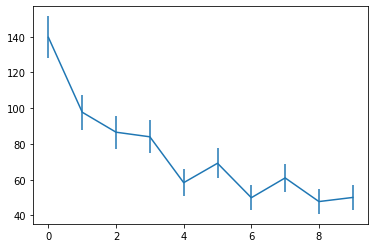

In [42]:
# this is the cell of code to give to students
def line(a, b, x):
  return a*x + b

np.random.seed(222)
y = np.array([120, 95, 82, 74, 66, 62, 59, 51, 53, 47]) 
y = y + np.random.randn(len(y)) * 10
yerr = np.sqrt(y)
x = np.arange(len(y))

plt.errorbar(x, y, yerr=yerr);

print("L2 unit test: result should be 111.93751462 -8.33237568:", minimize(l2, (10,40), args=(x, y, line)).x)
print("chi2 unit test: result should be 104.93611121 -7.21374685:", minimize(chi2, (10,40), args=(x, y, yerr, line)).x)



# Fit the two functions to the data by minimizing an objective function 


Use the l1 function as your objective function.

In [43]:
x = df.t.values
y = df.A.values
s = df.A_err.values

In [44]:
# Remember the Cauchy parameters we have defined: amp, x0, flattness, sigma
initialGuess_Roman_Cauchy = (max(y), peak, 1, .1)
initialGuess_OGLE_Cauchy = (max(y), peak, 1, 0.15)


In [45]:
# Remember the PSPL parameters we have defined: x0, tE, u0, fs

initialGuess_Roman_PSPL = (peak, .1, 0.02, 0.464796)
initialGuess_OGLE_PSPL = (peak, 0.15, 0.6, 1)


In [46]:
# Fitting the PSPL function to data

# Remember the PSPL parameters we have defined: x0, tE, u0, fs

l1Solution_PSPL = minimize(l1, initialGuess_Roman_PSPL, args=(x, y, PSPL), method = 'Nelder-Mead')
print(l1Solution_PSPL)
print("")
print("best fit parameters from the minimization of the l1: " + 
       "t0 {:.2f}, tE {:.2f}, u0 {:.2f}, fs {:.2f}".format(*l1Solution_PSPL.x))

 final_simplex: (array([[1.66465604e+02, 1.66712820e-01, 1.46238125e-02, 1.71480795e-01],
       [1.66465604e+02, 1.66685489e-01, 1.46267800e-02, 1.71507052e-01],
       [1.66465604e+02, 1.66697637e-01, 1.46254773e-02, 1.71499180e-01],
       [1.66465604e+02, 1.66797236e-01, 1.46145431e-02, 1.71395485e-01],
       [1.66465604e+02, 1.66681916e-01, 1.46272131e-02, 1.71517522e-01]]), array([129.39836332, 129.39836566, 129.39838174, 129.39838796,
       129.39839131]))
           fun: 129.39836332360485
       message: 'Optimization terminated successfully.'
          nfev: 392
           nit: 212
        status: 0
       success: True
             x: array([1.66465604e+02, 1.66712820e-01, 1.46238125e-02, 1.71480795e-01])

best fit parameters from the minimization of the l1: t0 166.47, tE 0.17, u0 0.01, fs 0.17


In [47]:
# Fitting the Cauchy function to data

# Remember the Cauchy parameters we have defined: amp, x0, flattness, sigma


l1Solution_cauchy = minimize(l1, initialGuess_Roman_Cauchy, args=(x, y, cauchy))
print(l1Solution_cauchy)
print("")
print("best fit parameters from the minimization of the l1: " + 
       "Amplitude {:.2f}, x0 {:.2f}, flattness {:.2f},  sigma {:.2f}".format(*l1Solution_cauchy.x))

      fun: 124.39289156697016
 hess_inv: array([[ 5.93364713e-01, -1.04195114e-03, -1.53029394e-02,
        -1.13391035e-03],
       [-1.04195114e-03,  2.01861255e-06,  1.73430070e-05,
         1.81148257e-06],
       [-1.53029394e-02,  1.73430070e-05,  2.38816877e-03,
         4.20024581e-05],
       [-1.13391035e-03,  1.81148257e-06,  4.20024581e-05,
         2.42494919e-06]])
      jac: array([  0.51705074, 176.93183994,   0.34373951, 124.54012489])
  message: 'Desired error not necessarily achieved due to precision loss.'
     nfev: 894
      nit: 14
     njev: 147
   status: 2
  success: False
        x: array([4.93482463e+00, 1.66463479e+02, 1.05374205e+00, 1.89082957e-02])

best fit parameters from the minimization of the l1: Amplitude 4.93, x0 166.46, flattness 1.05,  sigma 0.02


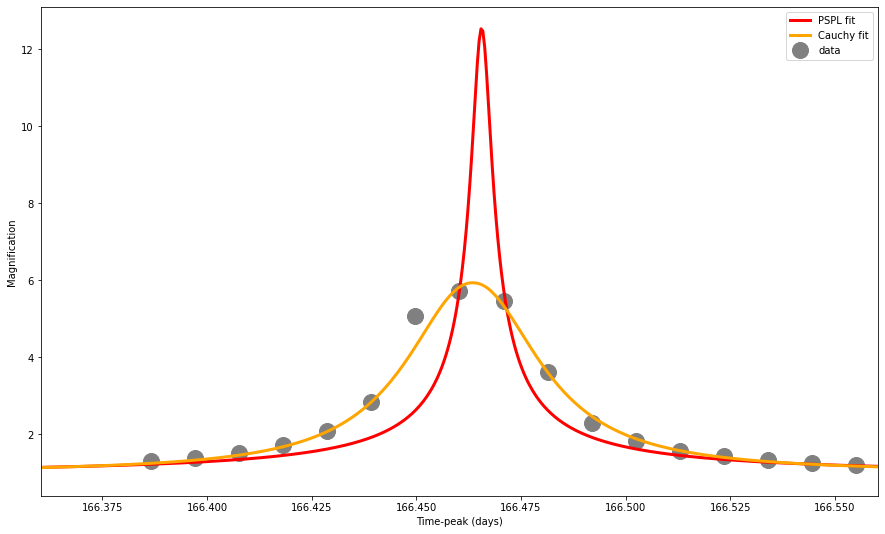

In [48]:
plt.figure(figsize=(15,9))
dt = 0.1
x_new = np.linspace(min(x), max(x), len(x)*100)
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt = 'o', ms=16,color='grey', zorder = -10, label = 'data')
plt.plot(x_new, PSPL(x_new, *l1Solution_PSPL.x),linewidth=3,color='red', label = 'PSPL fit')
plt.plot(x_new, cauchy(x_new, *l1Solution_cauchy.x),linewidth=3,color = 'orange', label = 'Cauchy fit')
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)')
plt.ylabel('Magnification')
plt.legend()

# Fit the two functions to the data by minimizing an objective function 


Use the l2 function as your objective function.

In [49]:
# Fitting the PSPL function to data

# Remember the PSPL parameters we have defined: x0, tE, u0, fs
#initialGuess = (peak, .1, 0.02, 0.464796)

l2Solution_PSPL = minimize(l2, initialGuess_Roman_PSPL, args=(x, y, PSPL),
                           bounds = ((None, None), (None, None), (None, None), (0, 1)),
                           method = 'L-BFGS-B')
print(l2Solution_PSPL)
print("")
print("best fit parameters from the minimization of the l2: " + 
       "t0 {:.2f}, tE {:.2f}, u0 {:.2f}, fs {:.2f}".format(*l2Solution_PSPL.x))

      fun: 1.5756758738909988
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
      jac: array([-7.24087457e-05,  1.62314606e-05,  4.32986980e-06, -5.92026006e-01])
  message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 320
      nit: 36
   status: 0
  success: True
        x: array([1.66462422e+02, 7.59465891e-02, 1.62627808e-01, 1.00000000e+00])

best fit parameters from the minimization of the l2: t0 166.46, tE 0.08, u0 0.16, fs 1.00


In [50]:
# Fitting the Cauchy function to data

x = df.t.values
y = df.A.values

# Remember the Cauchy parameters we have defined: amp, x0, flattness, sigma
#initialGuess = (max(y), peak, 1, .1)

l2Solution_cauchy = minimize(l2, initialGuess_Roman_Cauchy, args=(x, y, cauchy))
print(l2Solution_cauchy)
print("")
print("best fit parameters from the minimization of the l2: " + 
       "Amplitude {:.2f}, x0 {:.2f}, flattness {:.2f},  sigma {:.2f}".format(*l2Solution_cauchy.x))

      fun: 0.9139568089396447
 hess_inv: array([[ 3.74184964e-01, -5.81658599e-05, -8.99477686e-02,
         1.63032221e-03],
       [-5.81658599e-05,  4.70337711e-06,  4.15179788e-06,
        -3.18958506e-07],
       [-8.99477686e-02,  4.15179788e-06,  9.74347845e-02,
        -6.29583423e-04],
       [ 1.63032221e-03, -3.18958506e-07, -6.29583423e-04,
         1.33657365e-05]])
      jac: array([-1.49011612e-08,  8.70227814e-06, -2.23517418e-08,  8.41915607e-07])
  message: 'Optimization terminated successfully.'
     nfev: 204
      nit: 23
     njev: 34
   status: 0
  success: True
        x: array([ 4.93530190e+00,  1.66462129e+02,  1.19019193e+00, -2.02815458e-02])

best fit parameters from the minimization of the l2: Amplitude 4.94, x0 166.46, flattness 1.19,  sigma -0.02


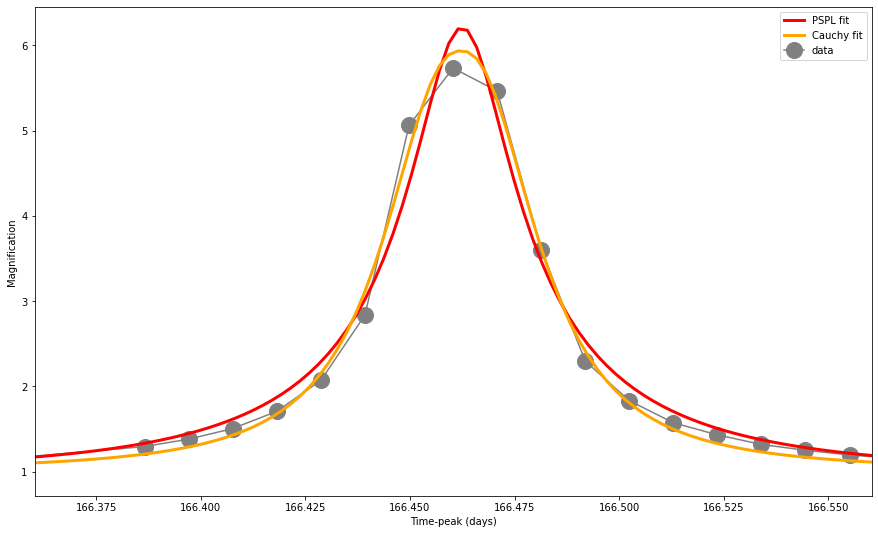

In [51]:
plt.figure(figsize=(15,9))
dt = .1
x_new = np.linspace(min(x), max(x), len(x)*20)
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt = '-o', ms=16,color='grey', zorder = -10, label = 'data')
plt.plot(x_new, PSPL(x_new, *l2Solution_PSPL.x),linewidth=3,color='red', label = 'PSPL fit')
plt.plot(x_new, cauchy(x_new, *l2Solution_cauchy.x),linewidth=3,color = 'orange', label = 'Cauchy fit')
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)')
plt.ylabel('Magnification')
plt.legend()

# Fit the two functions to the data by minimizing an objective function 


Use the ${\chi}^2$ function as your objective function.

In [52]:
# Fitting the PSPL function to data

# Remember the PSPL parameters we have defined: x0, tE, u0, fs
#initialGuess = (peak, .1, 0.02, 0.464796)

chi2Solution_PSPL = minimize(chi2, initialGuess_Roman_PSPL, args=(x, y, s, PSPL),
                             bounds = ((None, None), (None, None), (None, None), (0, 1)),
                             method = 'TNC')
print(chi2Solution_PSPL)
print("")
print("best fit parameters from the minimization of the chi squared: " + 
       "t0 {:.2f}, tE {:.2f}, u0 {:.2f}, fs {:.2f}".format(*chi2Solution_PSPL.x))

     fun: 61285.39234730862
     jac: array([-285060.86528068,  -54141.74229372,  -39425.28419429,
        -48092.62754861])
 message: 'Max. number of function evaluations reached'
    nfev: 100
     nit: 17
  status: 3
 success: False
       x: array([1.66462853e+02, 1.19787075e-01, 7.64703946e-02, 4.55030783e-01])

best fit parameters from the minimization of the chi squared: t0 166.46, tE 0.12, u0 0.08, fs 0.46


In [53]:
# Fitting the Cauchy function to data

# Remember the Cauchy parameters we have defined: amp, x0, flattness, sigma
#initialGuess = (max(y), peak, 1, .1)


chi2Solution_cauchy = minimize(chi2, initialGuess_Roman_Cauchy, args=(x, y, s, cauchy))
print(chi2Solution_cauchy)
print("")
print("best fit parameters from the minimization of the chi squared: " + 
       "Amplitude {:.2f}, x0 {:.2f}, flattness {:.2f},  sigma {:.2f}".format(*chi2Solution_cauchy.x))

      fun: 43534.10689968651
 hess_inv: array([[ 3.86806315e-05, -8.73250211e-09, -3.76670872e-06,
         1.47288403e-07],
       [-8.73250211e-09,  3.39928994e-10, -2.80934366e-10,
        -1.22696998e-11],
       [-3.76670872e-06, -2.80934367e-10,  2.51683443e-06,
        -3.21612992e-08],
       [ 1.47288403e-07, -1.22696998e-11, -3.21612992e-08,
         9.25558444e-10]])
      jac: array([ 0.00097656, -0.00976562, -0.00048828, -0.08984375])
  message: 'Desired error not necessarily achieved due to precision loss.'
     nfev: 480
      nit: 24
     njev: 78
   status: 2
  success: False
        x: array([ 5.05643890e+00,  1.66462320e+02,  1.08422599e+00, -1.92248663e-02])

best fit parameters from the minimization of the chi squared: Amplitude 5.06, x0 166.46, flattness 1.08,  sigma -0.02


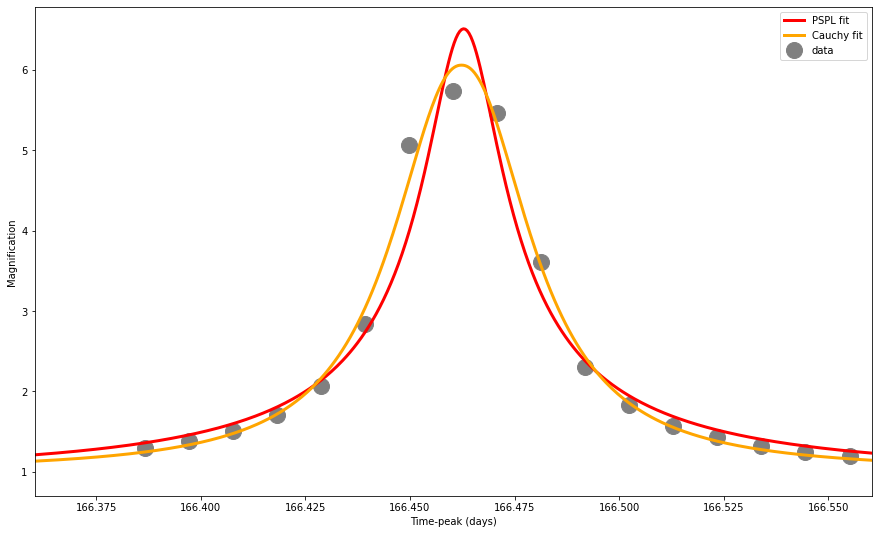

In [54]:
plt.figure(figsize=(15,9))
dt = 0.1
x_new = np.linspace(min(x), max(x), len(x)*100)
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt = 'o', ms=16,color='grey', zorder = -10, label = 'data')
plt.plot(x_new, PSPL(x_new, *chi2Solution_PSPL.x),linewidth=3,color='red', label = 'PSPL fit')
plt.plot(x_new, cauchy(x_new, *chi2Solution_cauchy.x),linewidth=3,color = 'orange', label = 'Cauchy fit')
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)')
plt.ylabel('Magnification')
plt.legend()

# Now let's fit a PSPL and a Cauchy with MCMC!



For fitting a PSPL model:

In [55]:

def log_likelihood(theta, x, y, yerr):
  x0, tE, u0, fs = theta
  # chi-squared = sum(((model - data) / error)**2)
  return -np.sum(((y - PSPL(x, x0, tE, u0, fs))**2) / yerr**2)

In [56]:
def log_prior(theta):
  x0, tE, u0, fs = theta
  if 0 < fs < 1 and tE > 0:
    return 0
  return -np.inf


In [57]:
def log_probability(theta, x, y, yerr):
  lp = log_prior(theta)
  if not np.isfinite(lp):
    return -np.inf 
  
  return lp + log_likelihood(theta, x, y, yerr)

In [58]:
#initial guess USE THE VALUE FROM THE L2
ig = l2Solution_PSPL.x

In [59]:
#initialize walkers
nwalkers = 32
ndim = len(ig)

In [60]:
pos = np.array(ig) + 1e-4 * np.random.randn(nwalkers, ndim)

In [61]:
pos.shape

(32, 4)

In [62]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, s))

In [63]:
sampler.run_mcmc(pos, 1000, progress=True);

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000/1000 [00:26<00:00, 38.46it/s]


In [64]:

samples = sampler.get_chain()

In [65]:
samples.shape

(1000, 32, 4)

In [66]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

In [31]:
mcmc = np.zeros((ndim, 3))
for i in range(ndim):
  mcmc[i] = np.percentile( flat_samples[:,i], [16, 50, 84])
params_PSPL = mcmc[:,1]

# issue 1: hitting the prior

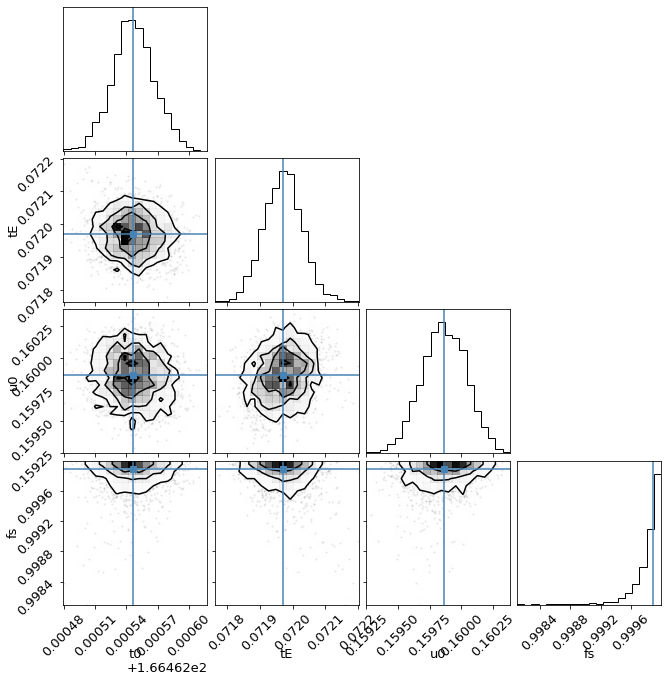

In [32]:
plt.rcParams["font.size"]= 13
fig = corner.corner(
    flat_samples, labels=["t0", "tE", "u0", "fs"], truths=mcmc[:,1]);


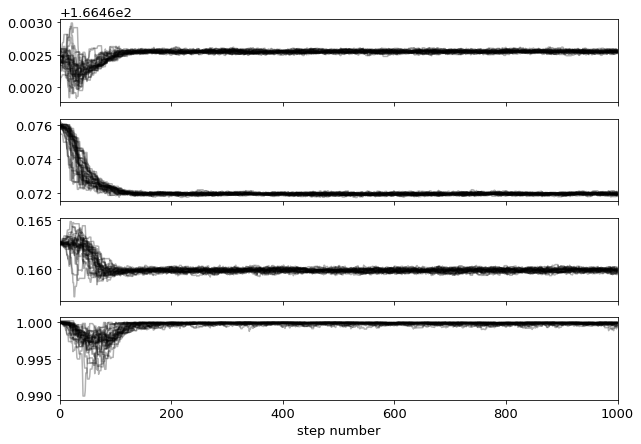

In [33]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
acorr(sampler.chain[0,:,0])
acorr(sampler.chain[1,:,0])

In [34]:
l2Solution_PSPL.x

array([1.66462422e+02, 7.59465891e-02, 1.62627808e-01, 1.00000000e+00])

## take 2

In [35]:
ig = l2Solution_PSPL.x
ig

array([1.66462422e+02, 7.59465891e-02, 1.62627808e-01, 1.00000000e+00])

In [36]:
VERBOSE = True
def log_prior(theta):
  x0, tE, u0, fs = theta
  
  if not (0 < fs < 1):
    print("fs fail")
    return -np.inf
  if not (tE > 0):
      print("tE fail")
      return -np.inf
  return 0

In [ ]:
pos = np.array(ig) + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, s))
sampler.run_mcmc(pos, 1000, progress=True);

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

mcmc = np.zeros((ndim, 3))
for i in range(ndim):
  mcmc[i] = np.percentile( flat_samples[:,i], [16, 50, 84])
params_PSPL = mcmc[:,1]
plt.rcParams["font.size"]= 13
fig = corner.corner(
    flat_samples, labels=["t0", "tE", "u0", "fs"], truths=mcmc[:,1]);


fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail


  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
  2%|▏         | 17/1000 [00:00<00:06, 162.20it/s]

fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail


  3%|▎         | 34/1000 [00:00<00:05, 165.51it/s]


fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail


...

 44%|████▍     | 445/1000 [00:03<00:05, 94.15it/s]

fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail
fs fail


Traceback (most recent call last):
  File "/usr/local/lib/python3.7/dist-packages/emcee/ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "<ipython-input-132-334819b39d42>", line 2, in log_probability
    lp = log_prior(theta)
  File "<ipython-input-170-f118678f9e81>", line 6, in log_prior
    print("fs fail")
  File "/usr/local/lib/python3.7/dist-packages/ipykernel/iostream.py", line 400, in write
    self.pub_thread.schedule(lambda : self._buffer.write(string))
  File "/usr/local/lib/python3.7/dist-packages/ipykernel/iostream.py", line 203, in schedule
    self._event_pipe.send(b'')
  File "/usr/local/lib/python3.7/dist-packages/zmq/sugar/socket.py", line 547, in send
    return super(Socket, self).send(data, flags=flags, copy=copy, track=track)
  File "zmq/backend/cython/socket.pyx", line 718, in zmq.backend.cython.socket.Socket.send
  File "zmq/backend/cython/socket.pyx", line 765, in zmq.backend.cython.socket.Socket.send
  File "zmq/backend

emcee: Exception while calling your likelihood function:
  params: [1.66462289e+02 3.16300270e-02 5.79965833e-01 5.39478277e+00]
  args: (array([ 112.505461,  112.515987,  112.526513, ..., 1825.220391,
       1825.230917, 1825.241444]), array([1.00311517, 1.00298584, 0.99819089, ..., 0.99391215, 0.99600886,
       1.00236894]), array([0.00399127, 0.00399168, 0.00399191, ..., 0.00399127, 0.00399144,
       0.00399107]))
  kwargs: {}
  exception:


KeyboardInterrupt: ignored

In [ ]:
ig = l2Solution_PSPL.x.copy()
ig[-1] = 0.5

100%|██████████| 1000/1000 [00:28<00:00, 35.63it/s]


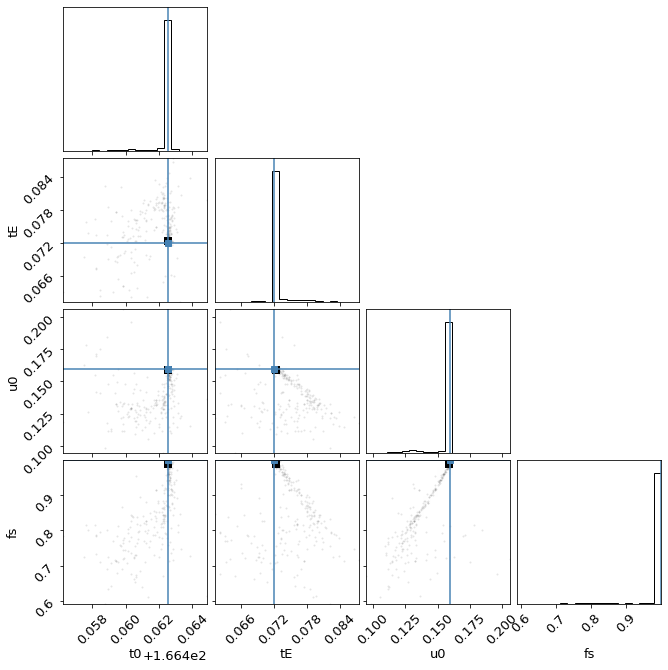

In [ ]:
pos = np.array(ig) + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, s))
sampler.run_mcmc(pos, 1000, progress=True);

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

mcmc = np.zeros((ndim, 3))
for i in range(ndim):
  mcmc[i] = np.percentile( flat_samples[:,i], [16, 50, 84])
params_PSPL = mcmc[:,1]
plt.rcParams["font.size"]= 13
fig = corner.corner(
    flat_samples, labels=["t0", "tE", "u0", "fs"], truths=mcmc[:,1]);


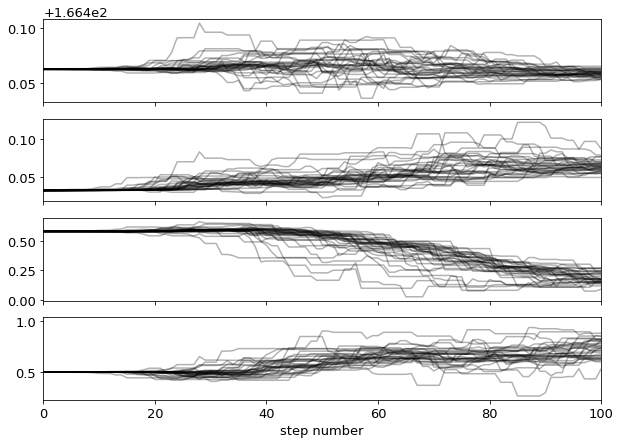

In [ ]:
# zoom in: the beginning of the chain should be cut
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, 100)#len(samples))
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
mcmc[:,1]

array([1.66462546e+02, 7.19796113e-02, 1.59837202e-01, 9.99865712e-01])

2 CPUs


  0%|          | 0/5000 [00:00<?, ?it/s]/usr/local/lib/python3.7/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [02:22<00:00, 35.00it/s]


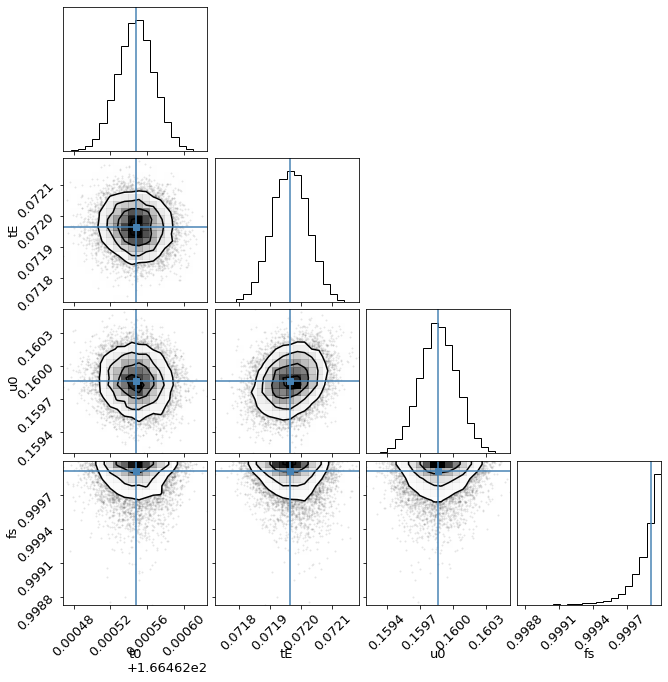

In [ ]:
from multiprocessing import Pool
from multiprocessing import cpu_count

ncpu = cpu_count()
print("{0} CPUs".format(ncpu))

pos = mcmc[:,1] + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool() as pool:
  sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, s))
  sampler.run_mcmc(pos, 5000, progress=True);
  


flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

mcmc = np.zeros((ndim, 3))
for i in range(ndim):
  mcmc[i] = np.percentile( flat_samples[:,i], [16, 50, 84])
params_PSPL = mcmc[:,1]
plt.rcParams["font.size"]= 13
fig = corner.corner(
    flat_samples, labels=["t0", "tE", "u0", "fs"], truths=mcmc[:,1]);

# For fitting a Cauchy distribution:

In [ ]:
def log_prior(theta):
  amp, x0, flattness, sigma = theta
  if flattness>0 and sigma > 0:
    return 0
  return -np.inf


In [ ]:
def log_likelihood(theta, x, y, yerr, ):
  amp, x0, flattness, sigma = theta
  return -np.sum(((y - cauchy(x, amp, x0, flattness, sigma))**2) / yerr**2)

In [ ]:
def log_probability(theta, x, y, yerr):
  lp = log_prior(theta)
  if not np.isfinite(lp):
    return -np.inf 
  
  return lp + log_likelihood(theta, x, y, yerr)

In [ ]:
#initial guess
ig = [max(y), peak, 1, .1]

In [ ]:
#initialize walkers
nwalkers = 32
ndim = len(ig)

In [ ]:
pos = np.array(ig) + 1e-4 * np.random.randn(nwalkers, ndim)

In [ ]:
pos.shape

(32, 4)

In [ ]:
ncpu = cpu_count()
print("{0} CPUs".format(ncpu))

with Pool() as pool:
  sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, s))
  sampler.run_mcmc(pos, 5000, progress=True);
  

2 CPUs


100%|██████████| 5000/5000 [08:47<00:00,  9.48it/s]


In [ ]:
samples = sampler.get_chain()

In [ ]:
samples.shape

(1000, 32, 4)

In [ ]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

In [ ]:
mcmc = np.zeros((ndim, 3))
for i in range(ndim):
  mcmc[i] = np.percentile( flat_samples[:,i], [16, 50, 84])
params_cauchy = mcmc[:,1]

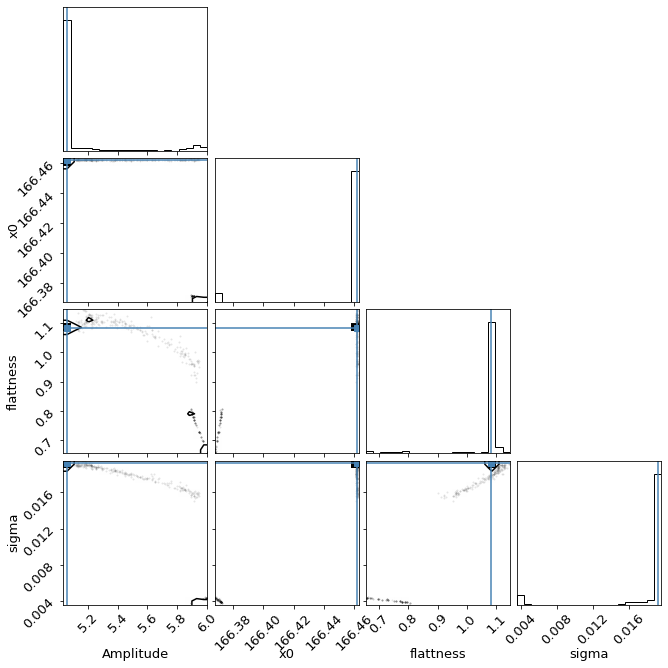

In [ ]:

plt.rcParams["font.size"]= 13
fig = corner.corner(
    flat_samples, labels=["Amplitude","x0","flattness","sigma"], truths=mcmc[:,1]);


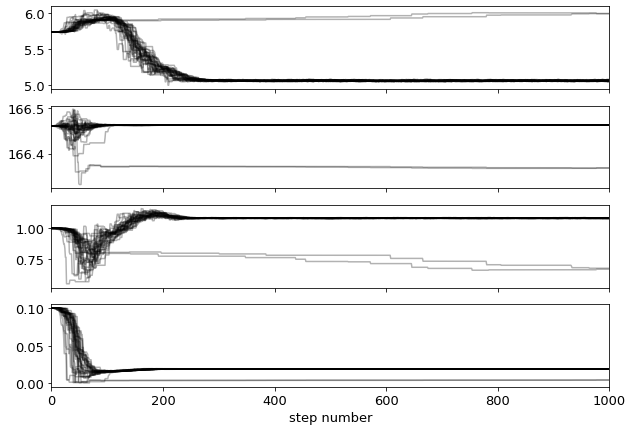

In [ ]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

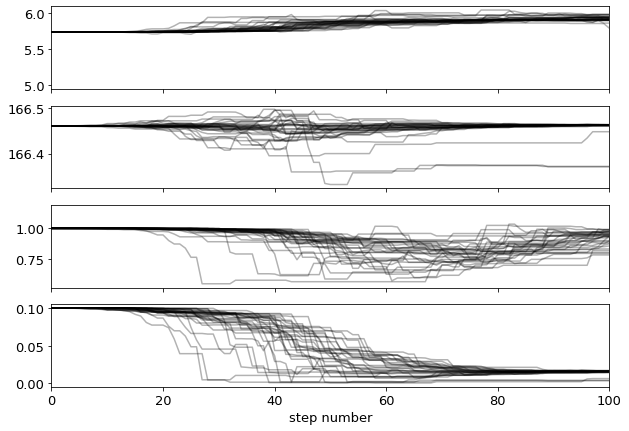

In [ ]:
# zoom in: the beginning of the chain should be cut
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, 100)#len(samples))
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

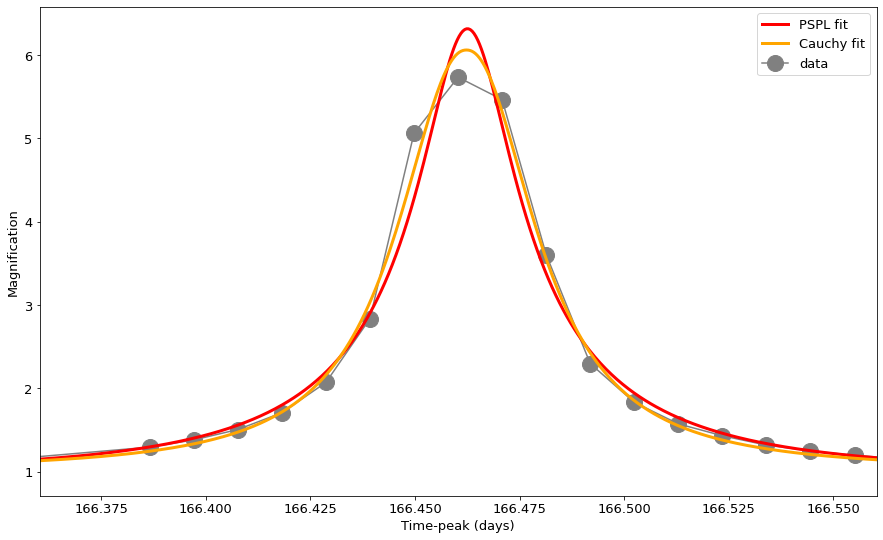

In [ ]:
plt.figure(figsize=(15,9))
dt = .1
x_new = np.linspace(min(x), max(x), len(x)*100)
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt = '-o', ms=16,color='grey', zorder = -10, label = 'data')
plt.plot(x_new, PSPL(x_new, *params_PSPL),linewidth=3,color='red', label = 'PSPL fit')
plt.plot(x_new, cauchy(x_new, *params_cauchy),linewidth=3,color = 'orange', label = 'Cauchy fit')
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)')
plt.ylabel('Magnification')
plt.legend()

# direct minimization with boundaries

In [ ]:
minimize?

In [ ]:
minimize

Object `tnc` not found.


In [ ]:
chi2Solution_PSPL = minimize(chi2, initialGuess_Roman_PSPL, args=(x, y, s, PSPL), 
                             method="TNC", bounds=[[-np.inf, np.inf],
                                                   [-np.inf, np.inf],
                                                   [0, np.inf],
                                                   [0, 1] 
                                                   ])


In [ ]:
chi2Solution_cauchy = minimize(chi2, initialGuess_Roman_Cauchy, args=(x, y, s, cauchy), 
                             method="TNC", bounds=[[-np.inf, np.inf],
                                                   [-np.inf, np.inf],
                                                   [0, np.inf],
                                                   [0, np.inf]
                                                   ])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:31: RuntimeWarning: divide by zero encountered in true_divide


In [ ]:
chi2Solution_PSPL.x, chi2Solution_cauchy.x

(array([1.66462853e+02, 1.19787075e-01, 7.64703946e-02, 4.55030783e-01]),
 array([5.05538546e+00, 1.66462320e+02, 1.08426746e+00, 1.92282052e-02]))

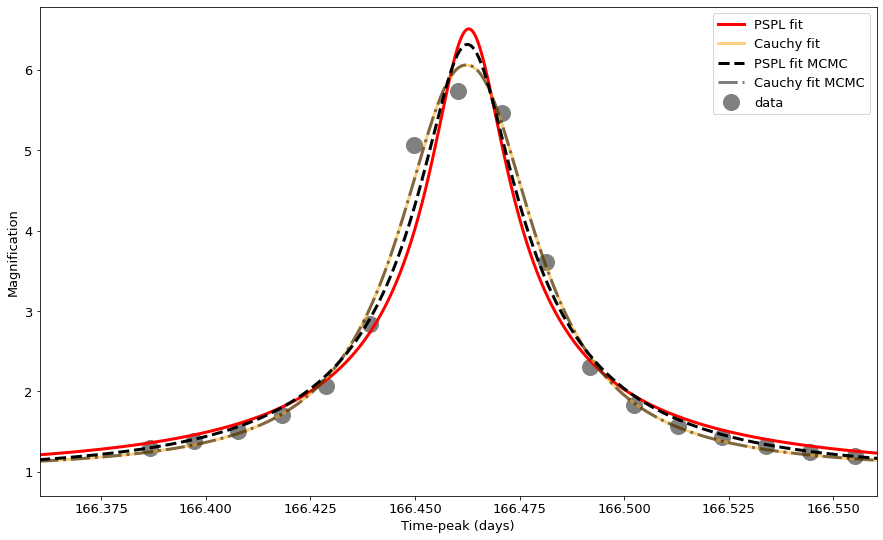

In [ ]:
plt.figure(figsize=(15,9))
dt = 0.1
x_new = np.linspace(min(x), max(x), len(x)*100)
plt.errorbar(df.t,df.A, yerr=df.A_err, fmt = 'o', ms=16,color='grey', zorder = -10, label = 'data')
plt.plot(x_new, PSPL(x_new, *chi2Solution_PSPL.x),linewidth=3,color='red', label = 'PSPL fit')
plt.plot(x_new, cauchy(x_new, *chi2Solution_cauchy.x),linewidth=3,color = 'orange', label = 'Cauchy fit', alpha=0.5)
plt.plot(x_new, PSPL(x_new, *params_PSPL),'--',linewidth=3,  color='k', label = 'PSPL fit MCMC')
plt.plot(x_new, cauchy(x_new, *params_cauchy), '-.', linewidth=3,color = 'k', label = 'Cauchy fit MCMC', alpha=0.5)
peak = df.t[np.argmax(df.A)]
plt.xlim(peak-dt,peak+dt)
plt.xlabel('Time-peak (days)')
plt.ylabel('Magnification')
plt.legend()